# Heisenberg model - Ground state

NetKet tutorial : https://netket.readthedocs.io/en/latest/tutorials/gs-heisenberg.html

### Defining Hamiltonian

In [7]:
# Import netket library
import netket as nk

# Import Json, this will be needed to load log files
import json

# Helper libraries
import matplotlib.pyplot as plt
import time

In [8]:
# Define a 1d chain
L = 12
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)

In [9]:
# Define the Hilbert space based on this graph
# We impose to have a fixed total magnetization of zero
hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=g.n_nodes)

In [10]:
# calling the Heisenberg Hamiltonian
ha = nk.operator.Heisenberg(hilbert=hi, graph=g)

### Exact diagonalization

In [11]:
# compute the ground-state energy (here we only need the lowest energy, and do not need the eigenstate)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print("The exact ground-state energy is E0=", exact_gs_energy)

# Just in case you can't do this calculation, here is the result
# exact_gs_energy = -39.14752260706246

The exact ground-state energy is E0= -21.549563669780852


### Jastrow ansatz

In [12]:
from flax import nnx
import jax.numpy as jnp
import jax


class Jastrow(nnx.Module):
    def __init__(self, N: int, *, rngs: nnx.Rngs):
        k1, k2 = jax.random.split(rngs.params())
        self.J = nnx.Param(0.01 * jax.random.normal(k1, (N, N), dtype=jnp.complex128))

        self.v_bias = nnx.Param(
            0.01 * jax.random.normal(k2, (N, 1), dtype=jnp.complex128)
        )

    def __call__(self, x):
        x = x.astype(jnp.complex128)  # keep the dtypes aligned
        quad = jnp.einsum("...i,ij,...j->...", x, self.J, x)
        lin = jnp.squeeze(x @ self.v_bias, -1)  # (...,N) @ (N,1) → (...,1)
        return quad + lin

In [13]:
ma = Jastrow(N=hi.size, rngs=nnx.Rngs(0))
print(ma)

Jastrow( # Param: 156 (2.5 KB)
  J=Param( # 144 (2.3 KB)
    value=Array(shape=(12, 12), dtype=dtype('complex128'))
  ),
  v_bias=Param( # 12 (192 B)
    value=Array(shape=(12, 1), dtype=dtype('complex128'))
  )
)


In [14]:
# Build the sampler
sa = nk.sampler.MetropolisExchange(hilbert=hi, graph=g)

# Optimizer
op = nk.optimizer.Sgd(learning_rate=0.01)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1, holomorphic=True)

# The variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1008)

# The ground-state optimization loop
gs = nk.VMC(hamiltonian=ha, optimizer=op, preconditioner=sr, variational_state=vs)

start = time.time()
gs.run(300, out="Jastrow")
end = time.time()

print("### Jastrow calculation")
print("Has", nk.jax.tree_size(vs.parameters), "parameters")
print("The Jastrow calculation took", end - start, "seconds")

  0%|          | 0/300 [00:00<?, ?it/s]

### Jastrow calculation
Has 156 parameters
The Jastrow calculation took 41.38420081138611 seconds


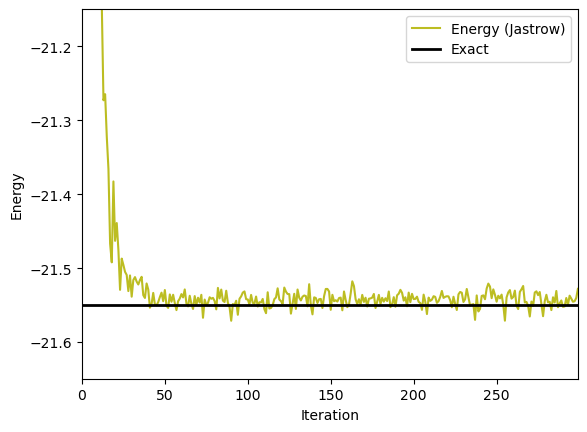

In [15]:
# import the data from log file
data_Jastrow = json.load(open("Jastrow.log"))

iters_Jastrow = data_Jastrow["Energy"]["iters"]
energy_Jastrow = data_Jastrow["Energy"]["Mean"]["real"]

fig, ax1 = plt.subplots()
ax1.plot(iters_Jastrow, energy_Jastrow, color="C8", label="Energy (Jastrow)")
ax1.set_ylabel("Energy")
ax1.set_xlabel("Iteration")
plt.axis([0, iters_Jastrow[-1], exact_gs_energy - 0.1, exact_gs_energy + 0.4])
plt.axhline(
    y=exact_gs_energy,
    xmin=0,
    xmax=iters_Jastrow[-1],
    linewidth=2,
    color="k",
    label="Exact",
)
ax1.legend()
plt.show()

### Restricted Boltzmann Machine (RBM)

In [16]:
# RBM ansatz with alpha=1
ma = nk.models.RBM(alpha=1)

In [17]:
# Build the sampler
sa = nk.sampler.MetropolisExchange(hilbert=hi, graph=g)

# Optimizer
op = nk.optimizer.Sgd(learning_rate=0.05)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1)

# The variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1008)

# The ground-state optimization loop
gs = nk.VMC(hamiltonian=ha, optimizer=op, preconditioner=sr, variational_state=vs)

start = time.time()
gs.run(out="RBM", n_iter=600)
end = time.time()

print("### RBM calculation")
print("Has", vs.n_parameters, "parameters")
print("The RBM calculation took", end - start, "seconds")

  0%|          | 0/600 [00:00<?, ?it/s]

### RBM calculation
Has 168 parameters
The RBM calculation took 79.09648585319519 seconds


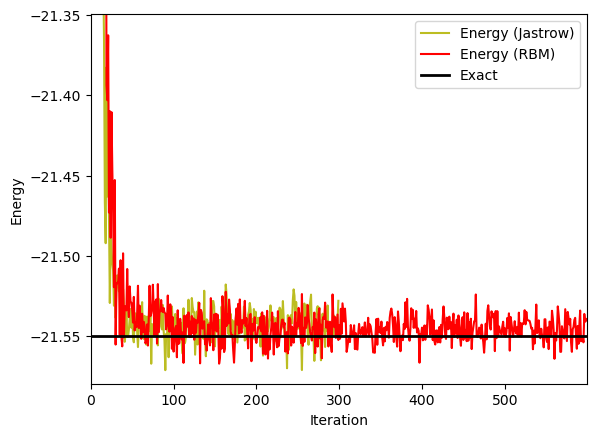

In [18]:
# import the data from log file
data = json.load(open("RBM.log"))

# Extract the relevant information
iters_RBM = data["Energy"]["iters"]
energy_RBM = data["Energy"]["Mean"]

fig, ax1 = plt.subplots()
ax1.plot(iters_Jastrow, energy_Jastrow, color="C8", label="Energy (Jastrow)")
ax1.plot(iters_RBM, energy_RBM, color="red", label="Energy (RBM)")
ax1.set_ylabel("Energy")
ax1.set_xlabel("Iteration")
plt.axis([0, iters_RBM[-1], exact_gs_energy - 0.03, exact_gs_energy + 0.2])
plt.axhline(
    y=exact_gs_energy, xmin=0, xmax=iters_RBM[-1], linewidth=2, color="k", label="Exact"
)
ax1.legend()
plt.show()

### RBM with lattices symmetries

Transational (all spots are equivalent)

In [19]:
## Symmetric RBM Spin Machine
ma = nk.models.RBMSymm(symmetries=g.translation_group(), alpha=1)

# Metropolis Exchange Sampling
# Notice that this sampler exchanges two neighboring sites
# thus preservers the total magnetization
sa = nk.sampler.MetropolisExchange(hi, graph=g)

# Optimizer
op = nk.optimizer.Sgd(learning_rate=0.01)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1)

# The variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1008)

# The ground-state optimization loop
gs = nk.VMC(hamiltonian=ha, optimizer=op, preconditioner=sr, variational_state=vs)

start = time.time()
gs.run(out="RBMSymmetric", n_iter=300)
end = time.time()

print("### Symmetric RBM calculation")
print("Has", vs.n_parameters, "parameters")
print("The Symmetric RBM calculation took", end - start, "seconds")

  0%|          | 0/300 [00:00<?, ?it/s]

### Symmetric RBM calculation
Has 14 parameters
The Symmetric RBM calculation took 35.980157136917114 seconds


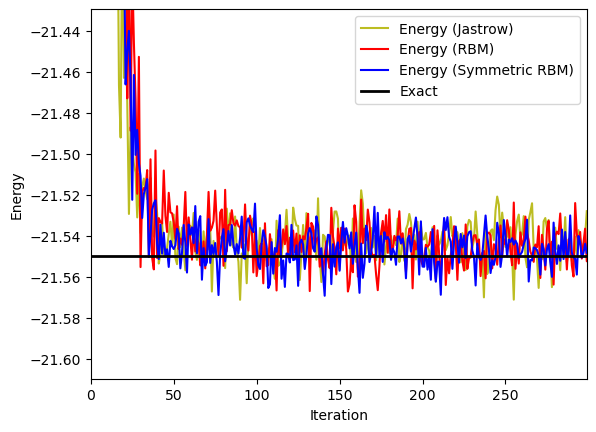

In [20]:
## import the data from log file
data = json.load(open("RBMSymmetric.log"))

# Extract the relevant information
iters_symRBM = data["Energy"]["iters"]
energy_symRBM = data["Energy"]["Mean"]

fig, ax1 = plt.subplots()
ax1.plot(iters_Jastrow, energy_Jastrow, color="C8", label="Energy (Jastrow)")
ax1.plot(iters_RBM, energy_RBM, color="red", label="Energy (RBM)")
ax1.plot(iters_symRBM, energy_symRBM, color="blue", label="Energy (Symmetric RBM)")

ax1.set_ylabel("Energy")
ax1.set_xlabel("Iteration")
if exact_gs_energy:
    plt.axis([0, iters_symRBM[-1], exact_gs_energy - 0.06, exact_gs_energy + 0.12])
    plt.axhline(
        y=exact_gs_energy,
        xmin=0,
        xmax=iters_RBM[-1],
        linewidth=2,
        color="k",
        label="Exact",
    )
ax1.legend()
plt.show()